## 生成模擬資料

In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [ ]:
# rng = np.random.default_rng(42)
# eps = 1e-8

# p = 100
# configs = [{'label':'linear', 'n':500, 'rho_xx':0.95, 'rho_xy':0.2, 'mean_shift':-4, 'std_x':1, 'std_y':0.8, "amp":1.5, "a":1, "b":-3}, 
#            {'label':'poly', 'n':500, 'rho_xx':0.65, 'rho_xy':-0.5, 'mean_shift':0, 'std_x':1.2, 'std_y':1.2, "amp":1.0, "a":1.2, "b":0},
#            {'label':'trig', 'n':500, 'rho_xx':0.3, 'rho_xy':0.8, 'mean_shift':4, 'std_x':0.6, 'std_y':1, "amp":2, "a":1.5, "b":3}]

# frames = []
# for k, cfg in enumerate(configs, 1):
#     m = p+1
#     Corr = np.full((m ,m), cfg['rho_xx'])
#     np.fill_diagonal(Corr, 1)
#     Corr[-1, :-1] = cfg['rho_xy']
#     Corr[:-1, -1] = cfg['rho_xy']

#     stds = np.r_[np.repeat(cfg['std_x'], p), cfg['std_y']]
#     D = np.diag(stds)
#     Sigma = D@Corr@D

#     # 正定修補
#     w, V = np.linalg.eigh(Sigma)
#     w = np.clip(w, 1e-6, None)
#     Sigma = (V*w)@V.T

#     mu = np.r_[np.repeat(cfg['mean_shift'], p), cfg['mean_shift']]
#     Z = rng.multivariate_normal(mu, Sigma, size=cfg['n'])

#     X = Z[:, :p]
#     y = Z[:, p]

#     X_obs = X.copy()

#     if cfg['label'] == 'poly':
#         idx_sq = [10, 30, 50]
#         idx_ix = (0, 1)
#         p_sq = [(X[:, i]**2) for i in idx_sq]
#         p_ix = X[:, idx_ix[0]]*X[:, idx_ix[1]]
#         p_all = p_sq+[p_ix]
#         for i, s in zip(idx_sq+[20], p_all):
#             z = (s-s.mean())/(s.std()+eps)
#             X_obs[:, i] = cfg["amp"]*z

#     if cfg['label'] == 'trig':
#         idx_trig = [(5, 'sin'), (15, 'cos'), (25, 'mix')]  # X6, X16, X26
#         for i, kind in idx_trig:
#             if kind == 'sin':
#                 t = np.sin(X[:, i])
#             elif kind == 'cos':
#                 t = np.cos(0.8*X[:, i])
#             else:
#                 t = np.sin(X[:, 1]+0.5*X[:, i])  # 混合
#             z = (t-t.mean())/(t.std()+eps)
#             X_obs[:, i] = cfg["amp"]*z

#     df = pd.DataFrame(X_obs, columns=[f'X{i+1}' for i in range(p)])
#     df['y_conti'] = y

#     logits = cfg["a"]*y+cfg["b"]
#     prob = 1/(1+np.exp(-logits))
#     df['y_binary'] = (rng.uniform(size=len(df))<prob).astype(int)
#     df['group'] = cfg['label']
#     frames.append(df)

# data = pd.concat(frames, ignore_index=True)

In [175]:
rng = np.random.default_rng(42)
eps = 1e-8

p = 100
frac_poly = 0.4
frac_trig = 0.4
configs = [{'label':'linear', 'n':500, 'rho_xx':0.95, 'rho_xy':0.2, 'mean_shift':-4, 'std_x':1, 'std_y':0.8, "amp":1, "a":-0.2, "b":-0.2}, 
           {'label':'poly', 'n':500, 'rho_xx':0.65, 'rho_xy':-0.5, 'mean_shift':0, 'std_x':1.2, 'std_y':1.2, "amp":2.0, "a":0.4, "b":0},
           {'label':'trig', 'n':500, 'rho_xx':0.3, 'rho_xy':0.8, 'mean_shift':4, 'std_x':0.6, 'std_y':1, "amp":2.5, "a":0.1, "b":0.2}]

frames = []
for k, cfg in enumerate(configs, 1):
    m = p+1
    Corr = np.full((m, m), cfg['rho_xx'])
    np.fill_diagonal(Corr, 1)
    Corr[-1, :-1] = cfg['rho_xy']
    Corr[:-1, -1] = cfg['rho_xy']

    stds = np.r_[np.repeat(cfg['std_x'], p), cfg['std_y']]
    D = np.diag(stds)
    Sigma = D@Corr@D

    # 正定修補
    w, V = np.linalg.eigh(Sigma)
    w = np.clip(w, 1e-6, None)
    Sigma = (V*w)@V.T

    mu = np.r_[np.repeat(cfg['mean_shift'], p), cfg['mean_shift']]
    Z = rng.multivariate_normal(mu, Sigma, size=cfg['n'])

    X = Z[:, :p]
    y = Z[:, p]
    X_obs = X.copy()

    if cfg['label'] == 'poly':
        k_non = int(round(p*frac_poly))
        idx = np.linspace(0, p-1, num=k_non, dtype=int)
        half = k_non//2
        T1 = X[:, idx[:half]]**2
        T2 = X[:, idx[half:k_non]]**3
        T1 = (T1-T1.mean(0))/(T1.std(0)+eps)
        T2 = (T2-T2.mean(0))/(T2.std(0)+eps)
        X_obs[:, idx[:half]] = cfg['amp']*T1
        X_obs[:, idx[half:k_non]] = cfg['amp']*T2
        pairs_ = idx[::2][:k_non//4]
        for i in pairs_:
            j = (i+1)%p
            t = X[:, i]*X[:,j]
            z = (t-t.mean())/(t.std()+eps)
            X_obs[:, i] = cfg["amp"]*z

    if cfg['label'] == 'trig':
        k_non = int(round(p*frac_trig))
        idx = np.linspace(0, p-1, num=k_non, dtype=int)
        third = max(1, k_non//3)
        i1 = idx[:third]
        i2 = idx[third:2*third]
        i3 = idx[2*third:k_non]
        S1 = np.sin(X[:, i1])
        C2 = np.cos(0.8*X[:, i2])
        S3 = np.sin(X[:, i3]+0.5*X[:, (i3+1)%p])
        for block in (S1, C2, S3):
            block -= block.mean(0)
            block /= (block.std(0)+eps)
        T2 = (T2-T2.mean(0))/(T2.std(0)+eps)
        X_obs[:, i1] = cfg["amp"]*S1
        X_obs[:, i2] = cfg["amp"]*C2
        X_obs[:, i3] = cfg["amp"]*S3

    df = pd.DataFrame(X_obs, columns=[f'X{i+1}' for i in range(X_obs.shape[1])])
    df['y_conti'] = y

    logits = cfg["a"]*y+cfg["b"]
    prob = 1/(1+np.exp(-logits))
    df['y_binary'] = (rng.uniform(size=len(df))<prob).astype(int)
    df['group'] = cfg['label']
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
print(data.groupby("group")["y_binary"].mean())

group
linear    0.638
poly      0.512
trig      0.642
Name: y_binary, dtype: float64


In [178]:
data

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X94,X95,X96,X97,X98,X99,X100,y_conti,y_binary,group
0,-4.244629,-4.241213,-4.473672,-4.359701,-4.325011,-4.539407,-4.388899,-4.547988,-3.927741,-4.439288,...,-3.944618,-4.070398,-3.944217,-4.072223,-4.018131,-4.488602,-4.154116,-3.236273,1,linear
1,-5.186348,-4.899514,-5.008662,-5.255213,-5.102779,-5.575488,-4.990944,-5.353966,-5.243150,-5.257893,...,-5.700784,-5.230920,-5.127527,-5.387434,-5.049749,-5.271655,-5.591968,-3.935734,0,linear
2,-3.936989,-4.216239,-3.920997,-4.035322,-4.133822,-3.860161,-4.070436,-4.230533,-3.874878,-4.148640,...,-4.464010,-3.867950,-3.877179,-3.796198,-3.868351,-4.321762,-4.201924,-4.519013,1,linear
3,-3.719330,-3.924180,-4.022675,-3.764837,-3.698623,-3.920968,-3.691583,-3.402932,-3.669375,-3.763610,...,-3.479337,-4.080551,-3.890847,-3.795727,-3.563283,-3.523263,-3.515200,-3.897732,1,linear
4,-4.149703,-4.953095,-4.805682,-4.482997,-4.215665,-4.499298,-4.427539,-4.961192,-4.376504,-4.514166,...,-4.208337,-4.377571,-4.426396,-4.496860,-4.188849,-4.264935,-4.233757,-3.877997,1,linear
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2.382580,4.210749,0.458292,5.999589,4.773242,-2.175920,4.857792,-2.418323,3.721725,3.977266,...,3.437391,4.541468,4.698749,1.493578,4.229736,4.905354,-1.303763,5.763336,1,trig
1496,-1.153928,4.364521,-1.855576,4.298563,4.606677,-2.403775,4.925626,0.840007,3.762323,4.194164,...,2.156789,3.991042,4.524394,-1.175752,3.774613,4.889659,4.866097,6.217859,1,trig
1497,-1.271521,4.221870,2.368361,4.491476,3.768018,-2.101513,4.565283,-1.539872,4.567366,3.930918,...,-0.108379,3.996082,4.027243,0.626081,3.287635,3.525497,-1.909330,4.350327,0,trig
1498,-1.362450,3.874150,1.065563,4.427395,4.845148,-0.585440,5.185858,-2.209313,4.065111,5.124886,...,3.502025,3.979877,4.487489,0.719096,3.831650,4.410187,-0.716882,4.855022,1,trig


<Axes: >

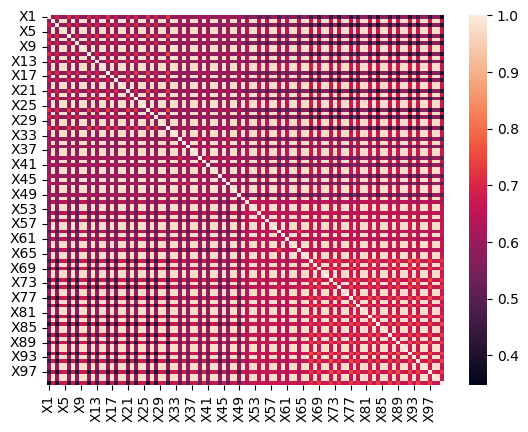

In [180]:
corr_ = data.drop(columns=['y_conti', 'y_binary', 'group']).corr()
sns.heatmap(data=corr_)

In [183]:
X = data.drop(columns=['y_conti', 'y_binary', 'group'])
y = data['y_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rfc = RandomForestClassifier(n_estimators=300, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
print(classification_report(y_pred, y_test))

              precision    recall  f1-score   support

           0       0.14      0.59      0.23        37
           1       0.93      0.61      0.74       338

    accuracy                           0.61       375
   macro avg       0.54      0.60      0.49       375
weighted avg       0.85      0.61      0.69       375



In [86]:
X.to_csv('generatedata.csv', sep='\t', index=False)

In [87]:
data['filename'] = [f'{i}' for i in range(1, 901)]
data['filename'] = data['filename'].astype(int)
# banknote = banknote.drop(columns=['class'])
# churn.to_csv('churn.csv', sep='\t', encoding='utf-8', index=False) 
data_order = pd.read_csv(r"C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\gap_生成.txt", sep='\t')
raw = '6  5  5  4  6  4  6  6  6  4  6  6  5  6  6  4  5  4  6  6  6  4  3  4  6  6  6  6  6  4  5  6  4  4  6  4  5  5  6  6  6  6  4  6  6  5  5  4  6  4  6  6  6  4  4  6  5  5  6  4  4  6  5  3  5  4  6  5  6  6  5  6  6  6  4  6  4  5  3  6  6  4  6  4  6  5  5  5  5  6  5  4  6  5  4  4  6  6  4  6  5  6  4  5  6  6  5  6  6  4  5  5  4  4  4  6  4  6  4  6  4  4  6  6  4  6  5  6  6  6  6  6  6  6  6  4  6  6  6  6  4  4  4  6  6  6  6  3  6  6  4  4  6  5  4  5  4  4  4  5  4  6  3  6  6  4  5  6  4  3  5  5  4  6  5  4  6  4  6  5  6  5  6  6  4  5  5  3  6  4  6  3  5  6  4  4  6  3  5  6  4  5  6  5  6  4  5  5  5  6  5  5  5  6  4  5  6  6  4  6  3  5  4  4  4  6  6  3  5  3  5  6  6  5  6  5  5  6  4  6  5  3  6  6  4  5  5  6  5  5  6  3  6  5  5  6  3  5  5  5  4  4  5  4  4  5  5  5  5  5  5  5  6  3  5  6  6  6  4  4  6  4  5  5  6  4  5  6  4  6  4  5  5  3  4  6  4  6  4  4  2  4  1  2  3  3  1  3  3  3  1  3  3  1  1  1  4  1  3  1  3  3  4  1  1  2  1  3  4  2  1  4  4  1  1  3  4  1  3  3  4  1  3  3  1  1  4  3  1  1  3  3  3  3  4  1  4  3  4  1  4  4  3  2  3  2  1  1  1  1  3  2  4  3  3  3  3  1  3  3  2  3  3  2  4  3  1  3  4  2  3  3  3  2  3  1  3  1  1  3  3  3  3  4  1  1  1  2  3  0  3  3  4  3  4  3  2  1  4  3  3  1  3  2  3  1  4  4  3  1  3  3  0  3  0  3  1  1  3  1  3  4  4  3  2  3  3  1  4  1  4  2  1  1  1  3  4  3  3  3  4  3  3  4  3  3  3  2  3  1  1  3  4  3  3  2  3  1  4  2  1  1  3  1  3  0  3  3  3  3  3  4  1  3  1  4  3  0  4  1  3  4  4  3  4  4  4  2  4  2  3  3  1  1  4  4  3  1  0  3  4  4  3  3  3  4  2  3  3  3  4  1  4  2  4  3  2  3  1  3  3  4  3  1  3  1  4  1  1  3  4  3  3  3  2  1  1  3  1  3  3  4  1  3  3  3  3  1  1  1  3  1  3  3  3  3  3  4  4  1  1  3  3  3  3  3  3  3  4  2  1  1  4  3  1  3  0  4  3  3  0  1  1  0  1  1  1  1  0  1  1  1  1  3  1  0  0  0  0  1  1  0  1  0  0  1  0  1  0  0  0  0  0  1  0  1  1  0  3  1  1  1  1  0  1  0  0  0  1  0  0  1  0  1  0  0  0  0  1  1  1  0  1  1  1  1  0  0  1  1  0  1  1  0  1  1  1  0  1  1  1  0  1  1  1  0  0  0  1  0  1  1  1  0  1  0  1  0  0  1  0  0  1  1  1  1  0  0  1  1  0  1  1  0  1  1  0  3  0  1  0  0  1  1  1  0  0  0  1  0  1  1  0  0  1  1  0  0  0  1  1  1  3  0  0  1  1  0  0  1  0  1  0  1  1  1  1  1  0  0  1  1  1  1  1  3  0  0  0  0  1  0  0  0  0  0  0  1  1  1  0  0  0  3  0  0  1  1  0  1  0  1  1  0  3  0  0  0  0  1  0  1  0  1  1  1  0  0  4  0  0  0  1  0  0  1  0  1  1  0  0  1  1  1  4  1  1  0  0  0  1  1  0  1  1  1  1  1  1  0  0  0  0  1  1  0  1  1  0  1  1  1  1  0  1  1  1  1  0  1  1  0  1  1  1  0  1  1  1  1  0  1  1  1  1  0  1  1  0  0  0  0  1  0  0  0  0  0  1  1  0  0  1  1  0  0  0  1  1  1'
raw_list = [int(i) for i in raw.split()]
data_order['gap_cluster'] = raw_list
data_order['filename'] = data_order['UNIQID'].str.lstrip('r').astype('int')+1
data_order = data_order.drop(columns=['UNIQID'])

data_merged = pd.merge(data, data_order[['gap_cluster', 'filename']], on='filename').drop(columns=['filename'])


In [88]:
data_merged

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,y_conti,y_binary,cluster,group,gap_cluster
0,-1.964663,-2.209083,-2.731579,-2.501521,-2.796274,-2.953928,-2.216127,-2.017412,-1.845129,-2.315443,-1.649761,0,1,linear,1
1,-2.832559,-2.762587,-2.812636,-2.732510,-2.649143,-3.202837,-2.493750,-2.776196,-2.787806,-2.117467,-2.833854,0,1,linear,0
2,-3.371079,-3.064903,-3.621315,-3.237752,-2.527004,-2.839673,-3.486611,-2.985096,-3.198200,-3.114407,-3.146604,0,1,linear,0
3,-0.997615,-1.353309,-1.550316,-1.617776,-1.281105,-1.335406,-1.172455,-0.819978,-1.006869,-0.888469,-1.562654,0,1,linear,1
4,-2.162843,-2.179108,-1.840399,-2.196576,-2.568656,-1.902844,-1.974808,-2.164011,-2.310945,-1.629522,-2.257693,0,1,linear,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2.248708,0.399692,2.637810,-0.032527,2.724071,-0.698466,1.946601,3.377968,2.697256,2.752211,3.003125,1,3,trig,6
896,2.518494,0.587972,1.933574,-0.184682,2.027676,-0.773327,1.910765,2.123007,1.856895,2.244466,2.568097,1,3,trig,4
897,2.338179,0.954043,2.292011,0.124665,1.289478,0.027633,1.747659,1.152467,2.368256,1.777728,1.223636,0,3,trig,6
898,2.244117,0.887833,1.983257,0.143249,2.525440,0.239416,2.393900,2.004917,1.959055,2.415797,2.224663,1,3,trig,6


In [89]:
# X = 特徵, y = 目標
X = data_merged.drop(columns=['y_conti', 'y_binary', 'cluster', 'group', 'gap_cluster'])
y = data_merged['y_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
# === 2) Linear SVC ===
lsvc = LinearSVC(random_state=42, max_iter=1000, class_weight='balanced')
model3 = lsvc.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)
print("\n=== Linear SVC ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred3, digits=4))


=== Linear SVC ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7820    0.7536    0.7675       138
           1     0.7518    0.7803    0.7658       132

    accuracy                         0.7667       270
   macro avg     0.7669    0.7670    0.7667       270
weighted avg     0.7672    0.7667    0.7667       270



In [97]:
# === 5) XGBoost ===
xgb = XGBClassifier(n_estimators=100, max_depth=2, max_leaves=2, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist')
model5 = xgb.fit(X_train, y_train)
y_pred5 = model5.predict(X_test)
print("\n=== XGBoost ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred5, digits=4))


=== XGBoost ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7907    0.7391    0.7640       138
           1     0.7447    0.7955    0.7692       132

    accuracy                         0.7667       270
   macro avg     0.7677    0.7673    0.7666       270
weighted avg     0.7682    0.7667    0.7666       270



In [94]:
# # === 6) LightGBM ===
lgbm = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, num_leaves=2, random_state=42, n_jobs=-1, class_weight='balanced')
model6 = lgbm.fit(X_train, y_train)
y_pred6 = model6.predict(X_test)
print("\n=== LightGBM ===")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred6, digits=4))

[LightGBM] [Info] Number of positive: 312, number of negative: 318
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2102
[LightGBM] [Info] Number of data points in the train set: 630, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

=== LightGBM ===

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7903    0.7101    0.7481       138
           1     0.7260    0.8030    0.7626       132

    accuracy                         0.7556       270
   macro avg     0.7582    0.7566    0.7553       270
weighted avg     0.7589    0.7556    0.7552       270



In [100]:
data_merged

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,y_conti,y_binary,cluster,group,gap_cluster
0,-1.964663,-2.209083,-2.731579,-2.501521,-2.796274,-2.953928,-2.216127,-2.017412,-1.845129,-2.315443,-1.649761,0,1,linear,1
1,-2.832559,-2.762587,-2.812636,-2.732510,-2.649143,-3.202837,-2.493750,-2.776196,-2.787806,-2.117467,-2.833854,0,1,linear,0
2,-3.371079,-3.064903,-3.621315,-3.237752,-2.527004,-2.839673,-3.486611,-2.985096,-3.198200,-3.114407,-3.146604,0,1,linear,0
3,-0.997615,-1.353309,-1.550316,-1.617776,-1.281105,-1.335406,-1.172455,-0.819978,-1.006869,-0.888469,-1.562654,0,1,linear,1
4,-2.162843,-2.179108,-1.840399,-2.196576,-2.568656,-1.902844,-1.974808,-2.164011,-2.310945,-1.629522,-2.257693,0,1,linear,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2.248708,0.399692,2.637810,-0.032527,2.724071,-0.698466,1.946601,3.377968,2.697256,2.752211,3.003125,1,3,trig,6
896,2.518494,0.587972,1.933574,-0.184682,2.027676,-0.773327,1.910765,2.123007,1.856895,2.244466,2.568097,1,3,trig,4
897,2.338179,0.954043,2.292011,0.124665,1.289478,0.027633,1.747659,1.152467,2.368256,1.777728,1.223636,0,3,trig,6
898,2.244117,0.887833,1.983257,0.143249,2.525440,0.239416,2.393900,2.004917,1.959055,2.415797,2.224663,1,3,trig,6


In [102]:
y_col = 'y_binary'
c_col = 'gap_cluster'
X = data_merged.drop(columns=['y_conti', 'y_binary', 'cluster', 'group', 'gap_cluster'])
y = data_merged[y_col]
c = data_merged[c_col]

strat_key = y.astype(str) + '|' + c.astype(str)
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(X, y, c, test_size=0.3, stratify=strat_key, random_state=42)

labels_all = np.sort(y.unique())
rows = []
confusion_matrix_= {}
classification_report_ = {}
for k in sorted(c_train.unique()):
    train_mask = (c_train == k)
    test_mask = (c_test == k)
    Xk_train, yk_train = X_train[train_mask], y_train[train_mask]
    Xk_test, yk_test = X_test[test_mask], y_test[test_mask]

    if len(yk_train.unique())<2 or len(yk_test)==0:
        rows.append({'cluster':k, 'n_train':len(yk_train), 'n_test':len(yk_test), 'Acc':np.nan, 'F1':np.nan, 'note':'類別不足或無測試樣本'})
        continue

    lir_ = LinearRegression()
    lir_.fit(Xk_train, yk_train)
    lir_y_score = lir_.predict(Xk_test)
    lir_y_hat = (lir_y_score>=0.5).astype(int)
    rows.append({'cluster':k, 'model':'linear_0.5', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'linear_0.5')] = classification_report(yk_test, lir_y_hat, digits=4)

    lsvm = LinearSVC(random_state=42, max_iter=1000, class_weight='balanced')
    lsvm.fit(Xk_train, yk_train)
    lsvm__y_hat = lsvm.predict(Xk_test)
    lsvm__y_prob = lsvm.decision_function(Xk_test)
    rows.append({'cluster':k, 'model':'lsvm', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'LinearSVC')] = classification_report(yk_test, lsvm__y_hat)

    rfc = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=2, max_leaf_nodes=2, n_jobs=-1, class_weight='balanced')
    rfc.fit(Xk_train, yk_train)
    rfc_y_hat = rfc.predict(Xk_test)
    rfc__y_proba = rfc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'rfc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'RandomForestClassifier')] = classification_report(yk_test, rfc_y_hat)

    xgbc = XGBClassifier(n_estimators=100, max_depth=2, max_leaves=2, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss', tree_method='hist')
    xgbc.fit(Xk_train, yk_train)
    xgbc_y_hat = xgbc.predict(Xk_test)
    xgbc__y_proba = xgbc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'xgbc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'XGBClassifier')] = classification_report(yk_test, xgbc_y_hat)

    lgbmc = LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=2, num_leaves=2, random_state=42, n_jobs=-1, class_weight='balanced', verbose=-1)
    lgbmc.fit(Xk_train, yk_train)
    lgbmc_y_hat = lgbmc.predict(Xk_test)
    lgbmc__y_proba = lgbmc.predict_proba(Xk_test)[:,1]
    rows.append({'cluster':k, 'model':'lgbmc', 'n_train':len(yk_train), 'n_test':len(yk_test)})
    classification_report_[(k, 'LGBMClassifier')] = classification_report(yk_test, lgbmc_y_hat)

report = pd.DataFrame(rows).sort_values(['cluster','model'])
report

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\USER\anaconda3\Lib\sit

,cluster,model,n_train,n_test
4,0,lgbmc,99,43
0,0,linear_0.5,99,43
1,0,lsvm,99,43
2,0,rfc,99,43
3,0,xgbc,99,43
9,1,lgbmc,163,70
5,1,linear_0.5,163,70
6,1,lsvm,163,70
7,1,rfc,163,70
8,1,xgbc,163,70


In [111]:
print(classification_report_[(2, 'linear_0.5')])
print(classification_report_[(2, 'XGBClassifier')])

              precision    recall  f1-score   support

           0     0.5000    0.5000    0.5000         2
           1     0.8000    0.8000    0.8000         5

    accuracy                         0.7143         7
   macro avg     0.6500    0.6500    0.6500         7
weighted avg     0.7143    0.7143    0.7143         7

              precision    recall  f1-score   support

           0       0.25      0.50      0.33         2
           1       0.67      0.40      0.50         5

    accuracy                           0.43         7
   macro avg       0.46      0.45      0.42         7
weighted avg       0.55      0.43      0.45         7

